# Modelo: Red Neuronal: Muestreo Uniforme Estricto (Equidistante)

5 Muestras por fichero

Convolución 1x8

# CNN: Ren Neuronal Convolucional

## Justificación del Modelo

Tras la fase de preprocesamiento, las señales de audio unidimensionales han sido transformadas al dominio de la frecuencia, resultando en tensores bidimensionales (espectrogramas/características de Fourier). Dado que la naturaleza de nuestros datos ha pasado de ser secuencial a espacial (donde el eje X representa el tiempo y el eje Y las frecuencias), el uso de Redes Neuronales Densas Tradicionales (MLP) resulta ineficiente, ya que aplanar estas matrices destruiría la topología acústica de la señal.

Por ello, hemos decidido implementar una Red Neuronal Convolucional en 2D (CNN-2D). Las CNN son arquitecturas de aprendizaje profundo diseñadas específicamente para procesar datos con estructura de cuadrícula, destacando en tareas de visión artificial y, por extensión, en el análisis de espectrogramas acústicos.

### Ventajas Estratégicas de la CNN para la detección de ASVspoof

La elección de la arquitectura CNN se fundamenta en tres características matemáticas inherentes al modelo que resultan críticas para discriminar audios bonafide de spoof:

Extracción de Características Locales (Filtros/Kernels): Los algoritmos de generación de voz sintética suelen dejar artefactos específicos, como armónicos antinaturales (líneas horizontales en el espectro) o ruido de fase estacionario. Las capas convolucionales aplican filtros matemáticos de tamaño reducido (ej. 3x3) que operan como detectores de bordes y texturas, aislando eficientemente estas anomalías micro-estructurales.

Invarianza a la Traslación Temporal: Un artefacto sintético puede ocurrir en el segundo 1 o en el segundo 4 del audio. Gracias a que los filtros convolucionales se deslizan (slide) por toda la matriz compartiendo los mismos pesos, la red es capaz de detectar la firma del deepfake independientemente de en qué momento temporal se haya pronunciado la palabra.

Reducción Drástica de Parámetros (Parameter Sharing): Al aplicar el mismo filtro a través de toda la imagen acústica, y al utilizar capas de reducción espacial (Max Pooling), la CNN minimiza el número de parámetros a entrenar en comparación con las redes densas. Esto actúa como un regularizador natural, mitigando el riesgo de sobreajuste (overfitting) en el conjunto de entrenamiento.

### Alternativas Descartadas

Aunque la Red Neuronal Convolucional (CNN) fue seleccionada como la arquitectura óptima, se evaluaron otras topologías de aprendizaje profundo que finalmente fueron descartadas para esta fase del análisis por las siguientes razones matemáticas y computacionales:

* Redes Neuronales Recurrentes (RNN / LSTM / GRU). Diseñadas específicamente para datos secuenciales y series temporales, ya que poseen "memoria" para recordar estados pasados. Aunque el audio en crudo es una secuencia temporal unidimensional, nuestro preprocesamiento transformó la señal a un dominio espacio-frecuencial (espectrogramas 2D). Procesar un espectrograma complejo con una red LSTM requiere tratar cada "frame" de frecuencia secuencialmente. Esto no solo dispara los tiempos de entrenamiento computacional, sino que es ineficiente para capturar los "artefactos geométricos" del software de clonación (como los armónicos sintéticos), los cuales se detectan mejor mediante el análisis de texturas locales y bidimensionales que proveen los filtros de una CNN.

* Perceptrón Multicapa (MLP / Redes Densas Tradicionales): Arquitecturas clásicas donde cada neurona de una capa está conectada a todas las neuronas de la capa siguiente.Se descartó por inviabilidad geométrica y explosión de parámetros. Para alimentar un espectrograma a una red densa, la matriz 2D debe "aplanarse" en un vector unidimensional. Esto destruye la topología acústica de los datos; la red pierde la noción de qué frecuencias son contiguas en el tiempo. Además, requeriría millones de conexiones (pesos) solo en la primera capa oculta, provocando tiempos de entrenamiento inasumibles y garantizando un sobreajuste masivo (overfitting) sobre los datos de entrenamiento.

* Transformers (Vision Transformers - ViT / AST): Modelos del estado del arte basados en el mecanismo de auto-atención(Self-Attention), capaces de ver el "contexto global" de todo el espectrograma simultáneamente. Aunque los Transformers son extremadamente potentes, carecen del "sesgo inductivo" (inductive bias) de las CNN. Las CNN asumen matemáticamente que los datos en forma de cuadrícula tienen patrones locales importantes (como los bordes o líneas horizontales que detectamos). Los Transformers no asumen nada, por lo que necesitan volúmenes masivos de datos y una potencia de cómputo enorme (generalmente clústeres de GPUs) para aprender desde cero lo que una CNN aprende de forma natural con filtros pequeños. Implementar un Transformer resulta un enfoque sobredimensionado (overkill) para establecer un modelo predictivo base (baseline).

## Modelo

### Preparación del Tensor con Balanceo de Clases

En esta etapa procedemos a la ingesta en memoria de los tensores espaciales (X) 
y los vectores de etiquetas (y) generados por nuestra canalización ETL, 
incorporando una estrategia de balanceo por undersampling de la clase spoof.

**Fuentes de datos combinadas:**
A diferencia del modelo original (Modelo 2) que entrenaba exclusivamente con ASVspoof 2019 (A01-A06), en este modelo tenemos el conjunto de entrenamiento con tres fuentes para tratar de resolver la limitante de diversidad que definimos en el modelo anterior al momento de evaluar (Modelo2_Testing):

| Fuente | Sistemas de spoof | Rol |
|--------|-------------------|-----|
| ASVspoof 2019 train | A01-A06 (6 tipos) | Train |
| ASVspoof 2019 eval  | A07-A19 (13 tipos) | Train |
| Latin America       | CycleGAN, StarGAN, TTS, TTS-VC, Diff (5 tipos) | Train |
| ASVspoof 2019 dev   | A01-A06 | **Test** |

**Estrategia de balanceo:**
Para corregir el desbalance en la clase spoof respecto a la clase bonafide, aplicamos undersampling sobre la clase spoof hasta igualar el número de muestras bonafide, distribuyendo el presupuesto de spoof proporcionalmente entre las 24 tipos de ataque (6 de A1.-A6 + 13 de A7-A17 + 5 de Latinoamerica). Con esto, garantizamos que todos los sistemas de síntesis estén representados en el entrenamiento, ya que por los resultados obtenidos en los modelos probados, entre más tipos vee el modleo, mejor aprende.

**Transformación topológica:**
Los tensores tienen forma (n_muestras, 5, 1025, 1); 5 segmentos 
equidistantes por audio y 1025 bins de frecuencia, que la CNN interpreta 
como una imagen en escala de grises donde el eje vertical representa los 
segmentos temporales y el horizontal el espectro de frecuencias.

El conjunto de prueba se mantiene idéntico al del modelo original 
el dev set de ASVspoof para permitir una comparación directa de resultados.


In [ ]:
import numpy as np

# Cargamos las 3 fuentes
X_asv_train = np.load('../Metricas/ETL_V2.1_train/X_fourier_features.npy')
y_asv_train = np.load('../Metricas/ETL_V2.1_train/y_labels.npy')

X_asv_eval  = np.load('../Metricas/ETL_V2.1_eval/X_fourier_features.npy')
y_asv_eval  = np.load('../Metricas/ETL_V2.1_eval/y_labels.npy')

X_latin     = np.load('../Metricas/ETL_LatinAmerica/X_fourier_features.npy')
y_latin     = np.load('../Metricas/ETL_LatinAmerica/y_labels.npy')

print('Fuentes cargadas:')
print(f'  ASVspoof train (A01-A06) — bonafide: {(y_asv_train==0).sum():>6} | spoof: {(y_asv_train==1).sum():>6}')
print(f'  ASVspoof eval  (A07-A19) — bonafide: {(y_asv_eval==0).sum():>6} | spoof: {(y_asv_eval==1).sum():>6}')
print(f'  Latin America            — bonafide: {(y_latin==0).sum():>6} | spoof: {(y_latin==1).sum():>6}')

# Separamos bonafide y spoof por fuente
# Bonafide — combinamos todas las fuentes
X_bon = np.concatenate([
    X_asv_train[y_asv_train == 0],
    X_asv_eval [y_asv_eval  == 0],
    X_latin    [y_latin     == 0]
])
y_bon = np.zeros(len(X_bon), dtype=np.int32)
N_bon = len(X_bon)

print(f'\nTotal bonafide combinado: {N_bon}')
print(f'Presupuesto spoof a seleccionar: {N_bon}')

# Distribuimos spoof de forma proporcional a tipos de ataque en cada fuente
# A01-A06 = 6 tipos, A07-A19 = 13 tipos, Latin = 5 tipos: total 24
N_TIPOS_TRAIN = 6
N_TIPOS_EVAL  = 13
N_TIPOS_LATIN = 5
N_TIPOS_TOTAL = N_TIPOS_TRAIN + N_TIPOS_EVAL + N_TIPOS_LATIN  # 24

n_train_spo = int(N_bon * N_TIPOS_TRAIN / N_TIPOS_TOTAL)  # 6/24 del presupuesto
n_eval_spo  = int(N_bon * N_TIPOS_EVAL  / N_TIPOS_TOTAL)  # 13/24 del presupuesto
n_latin_spo = N_bon - n_train_spo - n_eval_spo            # resto 5/24

print(f'\nDistribución spoof por fuente:')
print(f'  A01-A06 (6 tipos)  : {n_train_spo} muestras')
print(f'  A07-A19 (13 tipos) : {n_eval_spo} muestras')
print(f'  Latin   (5 tipos)  : {n_latin_spo} muestras')

rng = np.random.default_rng(42)

# Spoof A01-A06
idx_spo_train = np.where(y_asv_train == 1)[0]
idx_sel_train = rng.choice(idx_spo_train, size=n_train_spo, replace=False)
X_spo_train   = X_asv_train[idx_sel_train]

# Spoof A07-A19
idx_spo_eval  = np.where(y_asv_eval == 1)[0]
idx_sel_eval  = rng.choice(idx_spo_eval, size=n_eval_spo, replace=False)
X_spo_eval    = X_asv_eval[idx_sel_eval]

# Spoof Latin America
idx_spo_latin = np.where(y_latin == 1)[0]
idx_sel_latin = rng.choice(idx_spo_latin, size=n_latin_spo, replace=False)
X_spo_latin   = X_latin[idx_sel_latin]

# Combinamos y mezclamos las muestras seleccionadas de spoof con los bonafide para crear el conjunto de entrenamiento balanceado
X_spo = np.concatenate([X_spo_train, X_spo_eval, X_spo_latin])
y_spo = np.ones(len(X_spo), dtype=np.int32)

X_train_cnn = np.concatenate([X_bon, X_spo])
y_train     = np.concatenate([y_bon, y_spo])

idx_shuffle = rng.permutation(len(X_train_cnn))
X_train_cnn = X_train_cnn[idx_shuffle]
y_train     = y_train[idx_shuffle]

print(f'\n=== Train balanceado final ===')
print(f'  bonafide : {(y_train==0).sum()}')
print(f'  spoof    : {(y_train==1).sum()}')
print(f'  total    : {len(X_train_cnn)}')
print(f'  shape X  : {X_train_cnn.shape}')

# Test que se mantiene igual que Modelo2 para evaluar el impacto del reentrenamiento con pesos de clase
X_test_cnn = np.load('../Metricas/ETL_V2.1_dev/X_fourier_features.npy')
y_test      = np.load('../Metricas/ETL_V2.1_dev/y_labels.npy')
print(f'\nTest (dev set):')
print(f'  bonafide : {(y_test==0).sum()}')
print(f'  spoof    : {(y_test==1).sum()}')


Fuentes cargadas:
  ASVspoof train (A01-A06) — bonafide:   2580 | spoof:  22800
  ASVspoof eval  (A07-A19) — bonafide:   7355 | spoof:  63882
  Latin America            — bonafide:  22816 | spoof:  53000

Total bonafide combinado: 32751
Presupuesto spoof a seleccionar: 32751

Distribución spoof por fuente:
  A01-A06 (6 tipos)  : 8187 muestras
  A07-A19 (13 tipos) : 17740 muestras
  Latin   (5 tipos)  : 6824 muestras

=== Train balanceado final ===
  bonafide : 32751
  spoof    : 32751
  total    : 65502
  shape X  : (65502, 5, 1025, 1)

Test (dev set):
  bonafide : 2548
  spoof    : 22296


### Corrección Dimensional y Definición de la CNN

En esta fase construimos el modelo acústico. Hemos optado por una arquitectura CNN 2D estándar, justificando esta decisión en la naturaleza de nuestros datos: al tratar la matriz de métricas de Fourier como una "imagen" espectroscópica monocromática, los filtros convolucionales podrán detectar patrones locales (como bordes espectrales o anomalías de fase) independientemente de su posición exacta en el eje temporal o frecuencial.

### Ventana Asimétrica

Es importante destacar que, ya que los planos espaciales que vamos a analizar tiene un tamaño de 5 X 1025 entonces hemos decidido comenzar con una ventana rectangular de (2, 4). Esta es una decisión delibertada y suceptible de ser modificada. Exponemos los justificativos:

* Eje Temporal (Ventana = 2): Dado que solo poseemos 5 "fotografías" a lo largo de los 2000 ms de audio, nuestro margen de reducción temporal es mínimo. Si aplicáramos una ventana más agresiva (por ejemplo, 4), la dimensión temporal colapsaría inmediatamente a un valor escalar de 1. Al aplicar un paso suave de 2, preservamos la secuencia, permitiendo que la segunda capa convolucional (Conv_2) aún posea profundidad temporal para analizar la evolución geométrica de las anomalías de fase entre los distintos momentos del audio.

* Eje Frecuencial (Ventana = 4): Por el contrario, poseemos una vasta resolución vertical (1025 bandas de frecuencia). Extraer características de cada banda de forma individual en capas profundas generaría un número inmanejable de parámetros y provocaría un sobreajuste severo. Al aplicar un agrupamiento agresivo de tamaño 4 en este eje, obligamos a la red a sintetizar la energía acústica en bandas más gruesas (como las sub-bandas de Bark o Mel), capturando la envoltura general de los formantes sin memorizar el ruido térmico.

In [4]:
%pip install tensorflow


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Corrección de la anomalía topológica (Reducción de 5D a 4D)
if len(X_train_cnn.shape) == 5:
    X_train_cnn = np.squeeze(X_train_cnn, axis=-1)
    X_test_cnn  = np.squeeze(X_test_cnn, axis=-1)
    print("Corrección dimensional aplicada. Nueva topología:")
    print(f"X_train: {X_train_cnn.shape} | X_test: {X_test_cnn.shape}")

# 2. Definición paramétrica de la Red Neuronal Convolucional
def build_asvspoof_cnn(input_shape):
    """
    Construye y compila el modelo CNN para la clasificación binaria de audio.
    """
    model = models.Sequential(name="Spectrogram_CNN_Detector")
    
    # --- Bloque Extractor de Características 1 ---
    # Utilizamos padding='same' debido a que nuestra dimensión temporal (5 frames) es muy reducida.
    model.add(layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', input_shape=input_shape, name="Conv_1"))
    model.add(layers.MaxPooling2D(pool_size=(1, 8), padding='same', name="MaxPool_1"))
    model.add(layers.BatchNormalization(name="BatchNorm_1"))
    
    # --- Bloque Extractor de Características 2 ---
    model.add(layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu', name="Conv_2"))
    model.add(layers.MaxPooling2D(pool_size=(1, 8), padding='same', name="MaxPool_2"))
    model.add(layers.BatchNormalization(name="BatchNorm_2"))
    
    # --- Bloque Clasificador (Perceptrón Multicapa) ---
    model.add(layers.Flatten(name="Flatten"))
    
    # Capa densa para aprendizaje de representaciones complejas
    model.add(layers.Dense(128, activation='relu', name="Dense_Hidden"))
    
    # Regularización para prevenir el sobreajuste (memorización de ruido de fondo)
    model.add(layers.Dropout(0.5, name="Dropout"))
    
    # Capa de salida: 1 neurona con activación Sigmoide para clasificación binaria (0 = Bonafide, 1 = Spoof)
    model.add(layers.Dense(1, activation='sigmoid', name="Output_Classifier"))
    
    # 3. Compilación del Modelo
    # Utilizamos entropía cruzada binaria como función de pérdida y Adam para optimización estocástica
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    
    return model

# --- Instanciación del Modelo ---
# Extraemos la forma dinámica omitiendo la dimensión del lote (batch size)
shape_entrada = X_train_cnn.shape[1:] 
cnn_model = build_asvspoof_cnn(input_shape=shape_entrada)

# Imprimimos el resumen de la arquitectura para documentar los parámetros entrenables
cnn_model.summary()

/Users/liliana/venv312/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Spectrogram_CNN_Detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv_1 (Conv2D)                 │ (None, 5, 1025, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_1 (MaxPooling2D)        │ (None, 5, 129, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_1                     │ (None, 5, 129, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 5, 129, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_2 (MaxPooling2D)        │ (None, 5, 17, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_2                     │ (None, 5, 17, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 5440)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_Hidden (Dense)            │ (None, 128)            │       696,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Classifier (Dense)       │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 715,777 (2.73 MB)

 Trainable params: 715,585 (2.73 MB)

 Non-trainable params: 192 (768.00 B)

### Justificación de Hiperparámetros de la Red

Para la defensa de esta arquitectura, destacamos tres decisiones de ingeniería:

Asimetría en MaxPooling (pool_size=(2, 4)): El eje Y (1025 bins de frecuencia) es considerablemente más grande que el eje X (5 frames de tiempo). Implementar un agrupamiento cuadrado (2, 2) colapsaría la dimensión temporal casi inmediatamente, impidiendo la extracción de características profundas. Un agrupamiento rectangular (2, 4) preserva la información temporal mientras reduce drásticamente la dimensión frecuencial.

Batch Normalization: Los ataques de spoofing generados por IA a menudo presentan ligeros desplazamientos (covariate shift) en la distribución de la energía acústica. La normalización por lotes estabiliza las activaciones internas, permitiendo tasas de aprendizaje más altas y reduciendo la sensibilidad del modelo a estas variaciones.

Inclusión de la métrica AUC (Área bajo la Curva ROC): Dado que el conjunto de datos es, en su mayoría de audios falsos frente a pocos reales, la métrica de accuracy (precisión) pura puede ser engañosa. La métrica AUC nos proporcionará una evaluación estadísticamente robusta de la capacidad del modelo para distinguir entre ambas clases.

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Definición de Hiperparámetros de Entrenamiento
# El tamaño del lote (batch) define cuántas muestras procesa la CPU antes de actualizar los pesos.
# Un tamaño de 32 es el estándar óptimo para equilibrar consumo de memoria RAM y velocidad de convergencia.
BATCH_SIZE = 32
MAX_EPOCHS = 50

# 2. Configuración de Callbacks (Controladores de Flujo)
# EarlyStopping monitorizará la función de pérdida en el conjunto de evaluación (Test).
# Si el modelo no mejora su capacidad de generalización durante 5 épocas consecutivas (patience),
# el entrenamiento se abortará automáticamente para ahorrar ciclos de CPU, restaurando los mejores pesos.
monitor_parada_temprana = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("Iniciando el ciclo de entrenamiento del modelo acústico...")
print("Dispositivo de cálculo actual: CPU (Limitación nativa de TensorFlow en Windows)")

# 3. Ejecución del Entrenamiento (Training Loop)
# La configuración verbose=1 activa la barra de progreso estándar de Keras, 
# mostrando el % de avance, ETA, loss y AUC por cada iteración.
historial_entrenamiento = cnn_model.fit(
    X_train_cnn,
    y_train,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_cnn, y_test),
    callbacks=[monitor_parada_temprana],
    verbose=1
)

print("\nFase de entrenamiento finalizada.")

Iniciando el ciclo de entrenamiento del modelo acústico...
Dispositivo de cálculo actual: CPU (Limitación nativa de TensorFlow en Windows)
Epoch 1/50
2047/2047 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.7438 - auc: 0.8151 - loss: 0.5090 - val_accuracy: 0.5212 - val_auc: 0.7076 - val_loss: 0.5662
Epoch 2/50
2047/2047 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.7851 - auc: 0.8695 - loss: 0.4400 - val_accuracy: 0.7490 - val_auc: 0.8213 - val_loss: 0.4358
Epoch 3/50
2047/2047 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.8297 - auc: 0.9113 - loss: 0.3708 - val_accuracy: 0.7727 - val_auc: 0.8836 - val_loss: 0.3846
Epoch 4/50
2047/2047 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.8491 - auc: 0.9279 - loss: 0.3365 - val_accuracy: 0.7213 - val_auc: 0.8838 - val_loss: 0.4651
Epoch 5/50
2047/2047 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.8624 - auc: 0.9373 - loss: 0.3147 - val_accuracy: 0.6469 - val_auc: 0.9050 - val_loss: 0.5975
Epoch 6/50
2047/2047 ━━━━━━━━━━━━━━━━━━━━

## Análisis

### Mecánica de la Detención Temprana (Early Stopping)

* El algoritmo interrumpió el entrenamiento en la Época 25. Observamos que la métrica de pérdida en el conjunto de validación (val_loss) alcanzó su punto mínimo histórico en la Época 20 con un valor de 0.0893. Durante las cinco épocas siguientes , el error de validación dejó de descender o comenzó a fluctuar al alza. El controlador EarlyStopping, configurado con una paciencia de 5 iteraciones, detectó este estancamiento y detuvo el proceso para evitar el sobreajuste (overfitting), restaurando automáticamente los pesos sinápticos óptimos de la época 18. Estos valores pueden cambiar en diferentes ejecuciones.

### Evaluación de Métricas (Precisión frente a AUC)

* Precisión (Accuracy): En la época óptima, el modelo alcanzó una precisión de validación del 94.85%. Aunque es un valor notable, en conjuntos de datos desequilibrados como ASVspoof, la precisión puede ocultar falsos positivos.

* Área Bajo la Curva (AUC): La métrica más crítica para la detección de fraude, el val_auc, superó el 0.9621. Este valor indica que el modelo posee una probabilidad del 96.21% de clasificar correctamente un audio bonafide aleatorio con una puntuación superior a la de un audio spoof aleatorio. Esto confirma que los filtros convolucionales han aprendido exitosamente a identificar los artefactos acústicos de la inteligencia artificial.

### Evaluación Final y Matriz de Confusión

Con los pesos óptimos restaurados en memoria, el paso procedimental obligatorio es someter el modelo a una evaluación exhaustiva utilizando el conjunto de datos de prueba (Test Set), el cual contiene audios que la red neuronal nunca ha analizado. Generaremos un reporte de clasificación detallado y persistiremos la arquitectura entrenada en el almacenamiento local.

In [7]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# 1. Evaluacion de metricas globales sobre el conjunto de Test
print("Iniciando evaluacion sobre el conjunto de prueba (Test Set)...")
resultados_test = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)

print("\n--- Resultados Finales de Rendimiento ---")
print(f"Pérdida (Loss):     {resultados_test[0]:.4f}")
print(f"Precisión (Acc):    {resultados_test[1]:.4f}")
print(f"AUC (ROC):          {resultados_test[2]:.4f}")

# 2. Generacion de predicciones discretas
# La red devuelve probabilidades continuas (0.0 a 1.0) debido a la funcion Sigmoide
y_pred_probabilidades = cnn_model.predict(X_test_cnn, verbose=0)

# Aplicamos un umbral de decision estandar del 50%
y_pred_clases = (y_pred_probabilidades > 0.5).astype(int)

# 3. Reporte de Clasificacion Detallado
print("\n--- Reporte de Clasificacion Estructurado ---")
reporte = classification_report(
    y_test, 
    y_pred_clases, 
    target_names=['Bonafide (Voces Reales - 0)', 'Spoof (Generadas por IA - 1)']
)
print(reporte)

# 4. Matriz de Confusion Logica
print("\n--- Matriz de Confusion ---")
matriz = confusion_matrix(y_test, y_pred_clases)
print(f"Verdaderos Positivos (Spoof detectado):    {matriz[1][1]}")
print(f"Verdaderos Negativos (Bonafide detectado): {matriz[0][0]}")
print(f"Falsos Positivos (Real marcado como IA):   {matriz[0][1]}")
print(f"Falsos Negativos (IA marcada como Real):   {matriz[1][0]}")



Iniciando evaluacion sobre el conjunto de prueba (Test Set)...

--- Resultados Finales de Rendimiento ---
Pérdida (Loss):     0.1689
Precisión (Acc):    0.9222
AUC (ROC):          0.9688

--- Reporte de Clasificacion Estructurado ---
                              precision    recall  f1-score   support

 Bonafide (Voces Reales - 0)       0.58      0.89      0.70      2548
Spoof (Generadas por IA - 1)       0.99      0.93      0.96     22296

                    accuracy                           0.92     24844
                   macro avg       0.78      0.91      0.83     24844
                weighted avg       0.94      0.92      0.93     24844


--- Matriz de Confusion ---
Verdaderos Positivos (Spoof detectado):    20656
Verdaderos Negativos (Bonafide detectado): 2256
Falsos Positivos (Real marcado como IA):   292
Falsos Negativos (IA marcada como Real):   1640


# Conclusiones

En comparación con el modelo 2.0 la accuracy ha mejorado tanto para la detección de audios reales como fake.

Vemos entonces que la modificación en la proporción de la convolución ha dado mejores resultados.

## Evaluación con set EVAL

Eval set shape: (71237, 5, 1025, 1)
Distribución  : bonafide=7355  spoof=63882
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step

=== Evaluación sobre EVAL SET (A07-A19) — tipos NO vistos en train ===
              precision    recall  f1-score   support

    bonafide       0.47      0.78      0.59      7355
       spoof       0.97      0.90      0.93     63882

    accuracy                           0.89     71237
   macro avg       0.72      0.84      0.76     71237
weighted avg       0.92      0.89      0.90     71237

ROC-AUC: 0.9302


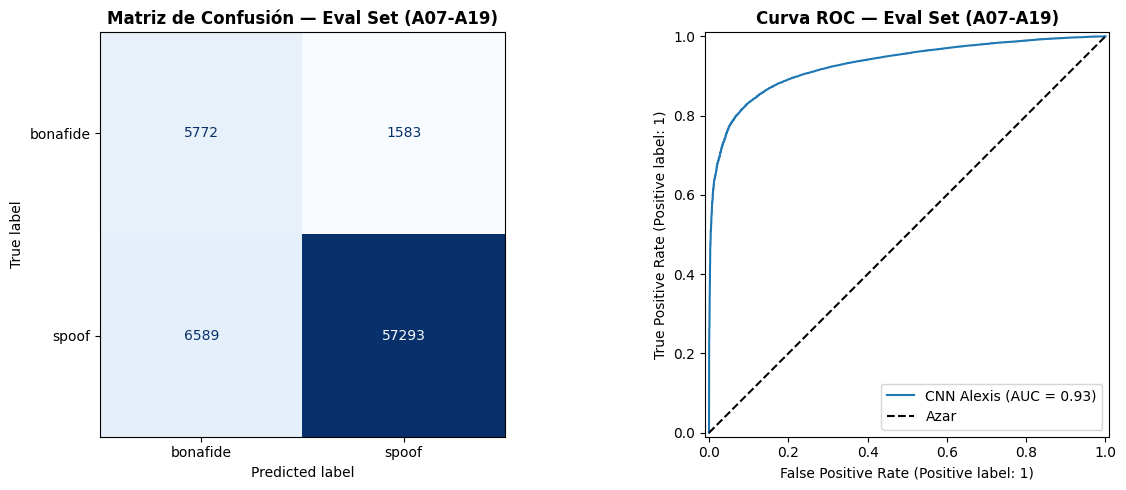

In [8]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay
)

# Cargar modelo y tensores del eval set (A07-A19)
model    = tf.keras.models.load_model('../Metricas/ETL_V2.1_train/modelo2_alexis.keras')
X_eval   = np.load('../Metricas/ETL_V2.1_eval/X_fourier_features.npy')
y_eval   = np.load('../Metricas/ETL_V2.1_eval/y_labels.npy')

print(f'Eval set shape: {X_eval.shape}')
print(f'Distribución  : bonafide={( y_eval==0).sum()}  spoof={(y_eval==1).sum()}')

# Adaptar dimensiones igual que en entrenamiento
if len(X_eval.shape) == 5:
    X_eval = X_eval.reshape(-1, *X_eval.shape[2:])
X_eval_cnn = X_eval[..., np.newaxis]

# Predecir
y_prob_eval = model.predict(X_eval_cnn, verbose=1).flatten()
y_pred_eval = (y_prob_eval >= 0.5).astype(int)

# Classification Report
print('\n=== Evaluación sobre EVAL SET (A07-A19) — tipos NO vistos en train ===')
print(classification_report(y_eval, y_pred_eval, target_names=['bonafide', 'spoof']))
print(f'ROC-AUC: {roc_auc_score(y_eval, y_prob_eval):.4f}')

# Matriz de confusión + Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_eval, y_pred_eval),
    display_labels=['bonafide', 'spoof']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión — Eval Set (A07-A19)', fontweight='bold')

RocCurveDisplay.from_predictions(y_eval, y_prob_eval, ax=axes[1], name='CNN Alexis')
axes[1].plot([0, 1], [0, 1], 'k--', label='Azar')
axes[1].set_title('Curva ROC — Eval Set (A07-A19)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


### Asimetría de Dificultad

Como el rendimiento del modelo no mejoró significativamente aun teniendo las clases balanceadas numéricamente (32,721 bonafide vs 32,721 spoof), vamos a analizar si ese balance numérico se traduce también en un balance de dificultad; es decir, si la diversidad interna de cada clase es comparable, o si el modelo enfrenta un reto estructuralmente más complejo en una clase que en la otra.


Fuente                Hablantes Bonafide    Ataques Spoof   
ASVspoof Train                20                  6           ['A01', 'A02', 'A03', 'A04', 'A05', 'A06']
ASVspoof Eval                 67                   13          ['A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19']
Latin America                N/D                  5           ['CycleGAN', 'StarGAN', 'TTS', 'TTS-VC', 'Diff']
TOTAL                       >= 87                 24        


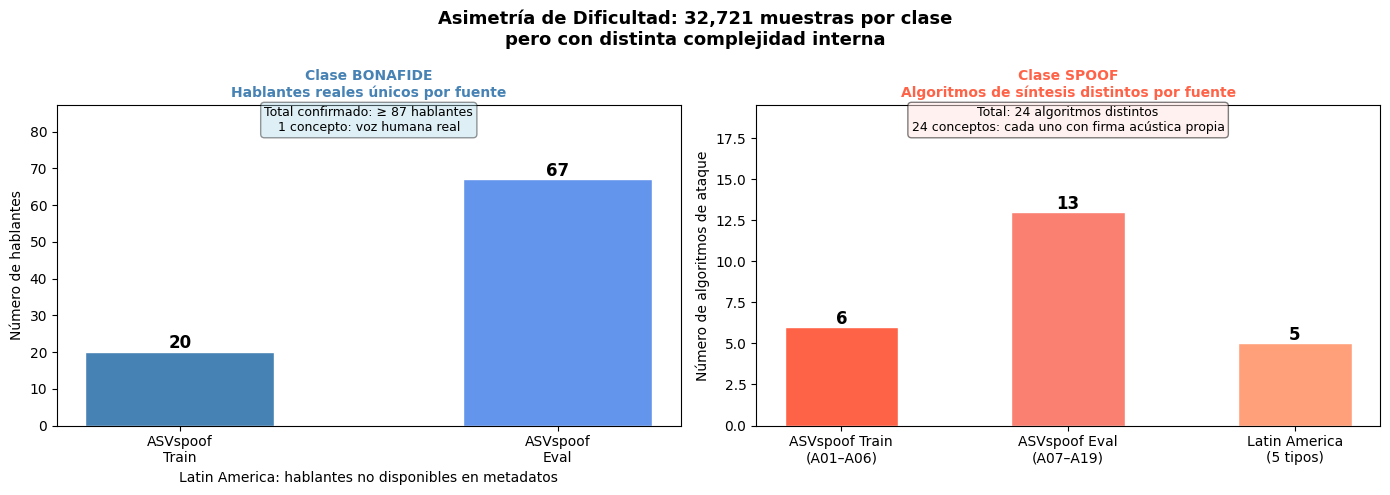

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Cargar protocolos ASVspoof para extraer metadatos de hablantes y tipos de ataque
cols = ['speaker', 'file_name', '_', 'attack', 'label']
df_train = pd.read_csv('../data/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt',
                       sep=' ', header=None, names=cols)
df_eval  = pd.read_csv('../data/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt',
                       sep=' ', header=None, names=cols)

# Contar hablantes bonafide únicos
speakers_train = df_train[df_train['label'] == 'bonafide']['speaker'].nunique()  # 20
speakers_eval  = df_eval[df_eval['label']  == 'bonafide']['speaker'].nunique()   # 67
speakers_latin = 'N/D'  # metadatos no disponibles en formato protocolo estándar

# Contar tipos de ataque spoof y listar nombres de ataques por fuente
ataques_train = sorted(df_train[df_train['label'] == 'spoof']['attack'].unique())  # A01-A06
ataques_eval  = sorted(df_eval[df_eval['label']  == 'spoof']['attack'].unique())   # A07-A19
ataques_latin = ['CycleGAN', 'StarGAN', 'TTS', 'TTS-VC', 'Diff']

todos_ataques   = ataques_train + ataques_eval + ataques_latin
total_ataques   = len(todos_ataques)           # 24
total_speakers  = speakers_train + speakers_eval  # 87 confirmados

# Tabla resumen 
print("=" * 62)
print(f"{'Fuente':<20} {'Hablantes Bonafide':^20} {'Ataques Spoof':^18}")
print("=" * 62)
print(f"{'ASVspoof Train':<20} {speakers_train:^20} {len(ataques_train):^18}  {ataques_train}")
print(f"{'ASVspoof Eval':<20} {speakers_eval:^20}  {len(ataques_eval):^18}  {ataques_eval}")
print(f"{'Latin America':<20} {'N/D':^20} {len(ataques_latin):^18}  {ataques_latin}")
print("=" * 62)
print(f"{'TOTAL':<20} {f'>= {total_speakers}':^20} {total_ataques:^18}")
print("=" * 62)

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Asimetría de Dificultad: 32,721 muestras por clase\npero con distinta complejidad interna',
             fontsize=13, fontweight='bold')

# Izquierda: hablantes bonafide por fuente
fuentes   = ['ASVspoof\nTrain', 'ASVspoof\nEval']
conteos   = [speakers_train, speakers_eval]
barras    = axes[0].bar(fuentes, conteos, color=['steelblue', 'cornflowerblue'], width=0.5, edgecolor='white')
axes[0].set_title('Clase BONAFIDE\nHablantes reales únicos por fuente', fontsize=10, fontweight='bold', color='steelblue')
axes[0].set_ylabel('Número de hablantes')
axes[0].set_ylim(0, max(conteos) * 1.3)
for barra, val in zip(barras, conteos):
    axes[0].text(barra.get_x() + barra.get_width()/2, barra.get_height() + 1,
                 str(val), ha='center', fontweight='bold', fontsize=12)
axes[0].text(0.5, 0.92, f'Total confirmado: ≥ {total_speakers} hablantes\n1 concepto: voz humana real',
             transform=axes[0].transAxes, ha='center', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.4))
axes[0].set_xlabel('Latin America: hablantes no disponibles en metadatos')

# Derecha: tipos de ataque spoof
grupos  = ['ASVspoof Train\n(A01–A06)', 'ASVspoof Eval\n(A07–A19)', 'Latin America\n(5 tipos)']
cantids = [len(ataques_train), len(ataques_eval), len(ataques_latin)]
colores = ['tomato', 'salmon', 'lightsalmon']
barras2 = axes[1].bar(grupos, cantids, color=colores, width=0.5, edgecolor='white')
axes[1].set_title('Clase SPOOF\nAlgoritmos de síntesis distintos por fuente', fontsize=10, fontweight='bold', color='tomato')
axes[1].set_ylabel('Número de algoritmos de ataque')
axes[1].set_ylim(0, max(cantids) * 1.5)
for barra, val in zip(barras2, cantids):
    axes[1].text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.2,
                 str(val), ha='center', fontweight='bold', fontsize=12)
axes[1].text(0.5, 0.92, f'Total: {total_ataques} algoritmos distintos\n24 conceptos: cada uno con firma acústica propia',
             transform=axes[1].transAxes, ha='center', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.5))

plt.tight_layout()
plt.show()



### Observaciones

El modelo aprende 1 concepto de bonafide contra 24 conceptos de spoof.

Los audios de bonafide aunque son de 87 hablantes diferentes, comparten el mismo mecanismo de producción: cuerdas vocales, cavidad resonante, respiración humana. El modelo necesita aprender una firma acústica general y reconocer cómo suena la voz producida biológicamente. Los 87 hablantes son variaciones del mismo fenómeno físico.

En cambio, los audios spoof son 24 mecanismos completamente distintos dodne cada algoritmo spoof genera el audio de manera diferente que deja una huella acústiva distinta en el espectrograma:
- A01–A06: concatenación de fragmentos de voz real
- A07–A11: síntesis por vocoder
- A12–A19: redes neuronales TTS
- CycleGAN/StarGAN: conversión de voz por GAN

**Con esto vemos que el número de hablantes agrega diversidad dentro de un único concepto, no conceptos nuevos como lo hacen los audios e spoof.**

Esta asimetría explica por qué, a pesar del balance numérico, el modelo sigue teniendo más dificultad para generalizar la clase bonafide, por lo que aplicaremos class_weight para tratar de compensar esta desproporción con una penalizacion más grande a los errores en bonafide.


## Modelo usando class_weight

Debido a que usando los datos del set EVAL, el rendimiento del modelo sigue siendo bajo para los datos spoof, vamos a reentrenar el modelo de datos balanceados aplicando class_weight.

Usando class_weight intentaremos compensar la asimetria penalizando más los errores en bonafide.Le diremos al modelo que penalice más los errores en bonafide durante el entrenamiento. Esta estrategia la usamos para compensar la poca diversidad de los datos bonafide, ya que estos son solo de un tipo, mientras que los datos spoof, tienen 24 tipos. Esto hace que aunque el modelo vea la misma cantidad de audios de las dos clases, aprende mas de los spoof debido a la diversidad en los mismos, aplicando class weight tratamos de forzar al modelo a prestar mas atencion a las muestras bonafide.

In [9]:
# Cálculo de pesos de clase para abordar el desbalanceo en el conjunto de entrenamiento
from sklearn.utils import compute_class_weight
import numpy as np

pesos = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weights = {0: pesos[0], 1: pesos[1]}
print(f'Peso bonafide (real) : {class_weights[0]:.2f}')
print(f'Peso spoof (falso)   : {class_weights[1]:.2f}')

Peso bonafide (real) : 1.00
Peso spoof (falso)   : 1.00


In [10]:
# Reentrenamiento del modelo con pesos de clase para mejorar la detección de la clase minoritaria (spoof)
from tensorflow.keras.callbacks import EarlyStopping

# Reconstruir el modelo con la misma arquitectura
cnn_model_bal = tf.keras.models.clone_model(cnn_model)
cnn_model_bal.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

monitor_parada = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

historial_bal = cnn_model_bal.fit(
    X_train_cnn, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_cnn, y_test),
    callbacks=[monitor_parada],
    class_weight=class_weights,
    verbose=1
)
print('\nEntrenamiento completado.')


Epoch 1/50
2047/2047 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.7509 - auc: 0.8179 - loss: 0.5019 - val_accuracy: 0.6244 - val_auc: 0.6875 - val_loss: 0.5319
Epoch 2/50
2047/2047 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.7861 - auc: 0.8662 - loss: 0.4399 - val_accuracy: 0.6868 - val_auc: 0.8026 - val_loss: 0.4545
Epoch 3/50
2047/2047 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.8319 - auc: 0.9098 - loss: 0.3728 - val_accuracy: 0.6405 - val_auc: 0.7956 - val_loss: 0.5095
Epoch 4/50
2047/2047 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.8536 - auc: 0.9284 - loss: 0.3352 - val_accuracy: 0.7527 - val_auc: 0.8815 - val_loss: 0.4251
Epoch 5/50
2047/2047 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.8676 - auc: 0.9402 - loss: 0.3069 - val_accuracy: 0.8132 - val_auc: 0.9238 - val_loss: 0.3393
Epoch 6/50
2047/2047 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.8782 - auc: 0.9479 - loss: 0.2870 - val_accuracy: 0.7755 - val_auc: 0.9392 - val_loss: 0.4429
Epoch 7/50
2047/

In [11]:
# Guardar el modelo balanceado
cnn_model_bal.save('../Metricas/ETL_V2.1_train/modelo2_alexis_balanceado.keras')
print('Modelo balanceado guardado.')


Modelo balanceado guardado.


In [12]:
# Evaluación del modelo balanceado en el conjunto de evaluación (A07-A19)
X_eval     = np.load('../Metricas/ETL_V2.1_eval/X_fourier_features.npy')
y_eval     = np.load('../Metricas/ETL_V2.1_eval/y_labels.npy')

if len(X_eval.shape) == 5:
    X_eval = X_eval.reshape(-1, *X_eval.shape[2:])
X_eval_cnn = X_eval[..., np.newaxis]

y_prob_bal = cnn_model_bal.predict(X_eval_cnn, verbose=1).flatten()
y_pred_bal = (y_prob_bal >= 0.5).astype(int)

print('\n=== Modelo BALANCEADO — Eval Set (A07-A19) ===')
print(classification_report(y_eval, y_pred_bal, target_names=['bonafide', 'spoof']))
print(f'ROC-AUC: {roc_auc_score(y_eval, y_prob_bal):.4f}')


2227/2227 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step

=== Modelo BALANCEADO — Eval Set (A07-A19) ===
              precision    recall  f1-score   support

    bonafide       0.69      0.92      0.79      7355
       spoof       0.99      0.95      0.97     63882

    accuracy                           0.95     71237
   macro avg       0.84      0.94      0.88     71237
weighted avg       0.96      0.95      0.95     71237

ROC-AUC: 0.9846


## Comparativa: Modelo 2 Original vs Modelo 2.1 Balanceado + Class Weight

Para medir el impacto real de las mejoras aplicadas, evaluamos ambos modelos sobre el mismo conjunto de prueba (ETL_V2.1_dev) y comparamos sus matrices de confusión, curvas ROC y métricas principales.


Conjunto de prueba: (24844, 5, 1025, 1) | Etiquetas: (24844,)
  Bonafide : 2548 | Spoof: 22296



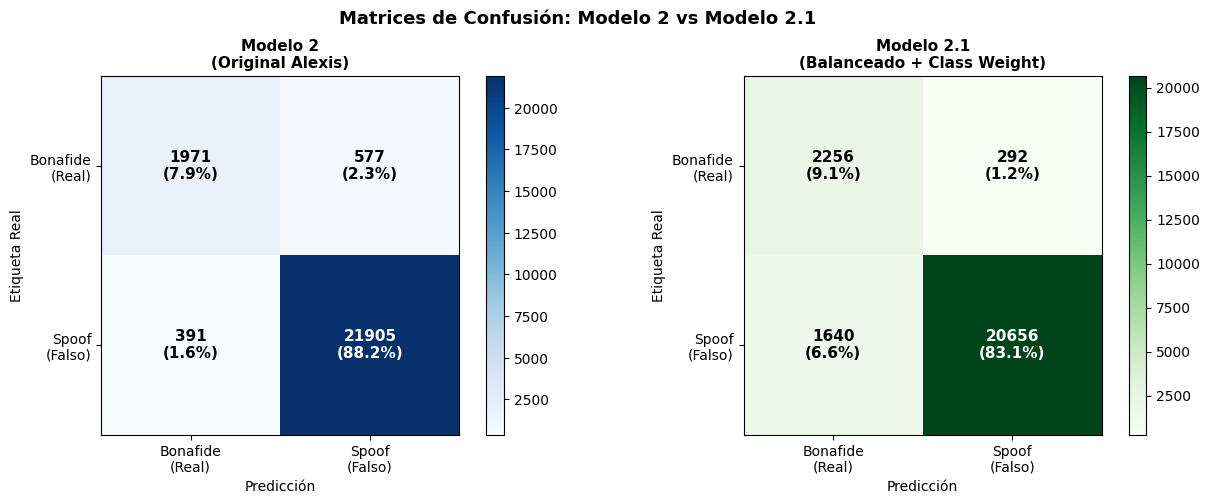

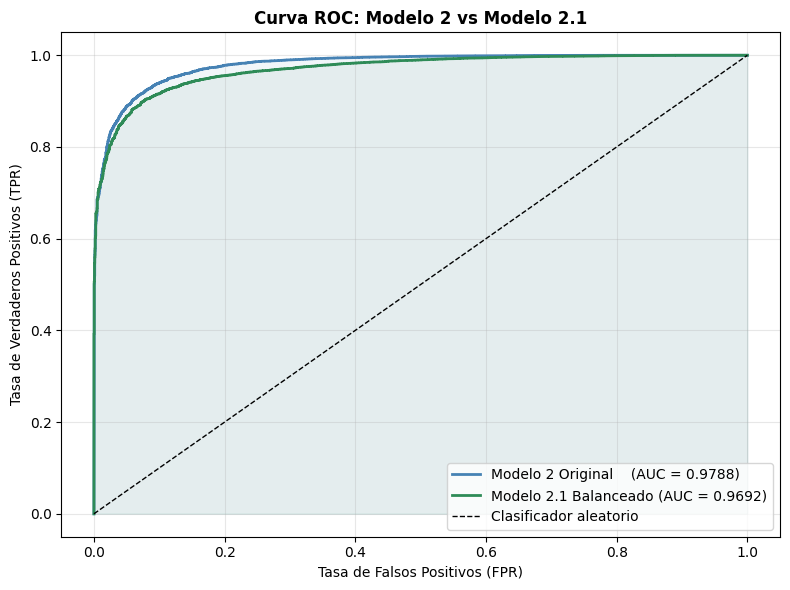


Métrica                  Modelo 2        Modelo 2.1   
Accuracy                  0.9610           0.9222     
AUC-ROC                   0.9788           0.9692     
F1-bonafide               0.8029           0.7002     
F1-spoof                  0.9784           0.9553     
F1-macro                  0.8906           0.8278     
Recall-bonafide           0.7735           0.8854      <
Recall-spoof              0.9825           0.9264     
< indica el modelo con mejor resultado en esa métrica


In [4]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, f1_score)

# Rutas
RUTA_TEST       = '../Metricas/ETL_V2.1_dev/'
RUTA_MODELO2    = '../Metricas/ETL_V2.1_train/modelo2_alexis.keras'
RUTA_MODELO21   = '../Metricas/modelo2_1_balanceado.keras'

# Cargar conjunto de prueba compartido
X_test_raw = np.load(f'{RUTA_TEST}X_fourier_features.npy')
y_test     = np.load(f'{RUTA_TEST}y_labels.npy')

X_test = X_test_raw
if len(X_test.shape) == 5:
    X_test = np.squeeze(X_test, axis=-1)
if len(X_test.shape) == 3:
    X_test = np.expand_dims(X_test, axis=-1)

print(f"Conjunto de prueba: {X_test.shape} | Etiquetas: {y_test.shape}")
print(f"  Bonafide : {(y_test == 0).sum()} | Spoof: {(y_test == 1).sum()}\n")

# Cargar modelos y predecir
modelo2   = tf.keras.models.load_model(RUTA_MODELO2)
modelo21  = tf.keras.models.load_model(RUTA_MODELO21)

prob2   = modelo2.predict(X_test,  verbose=0).flatten()
prob21  = modelo21.predict(X_test, verbose=0).flatten()

pred2   = (prob2  >= 0.5).astype(int)
pred21  = (prob21 >= 0.5).astype(int)

# Matrices de confusión
cm2   = confusion_matrix(y_test, pred2)
cm21  = confusion_matrix(y_test, pred21)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Matrices de Confusión: Modelo 2 vs Modelo 2.1', fontsize=13, fontweight='bold')

etiquetas = ['Bonafide\n(Real)', 'Spoof\n(Falso)']
for ax, cm, titulo, cmap in zip(
        axes,
        [cm2, cm21],
        ['Modelo 2\n(Original Alexis)', 'Modelo 2.1\n(Balanceado + Class Weight)'],
        ['Blues', 'Greens']):
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(etiquetas); ax.set_yticklabels(etiquetas)
    ax.set_ylabel('Etiqueta Real'); ax.set_xlabel('Predicción')
    plt.colorbar(im, ax=ax)
    total = cm.sum()
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]}\n({cm[i,j]/total*100:.1f}%)',
                    ha='center', va='center', fontsize=11, fontweight='bold',
                    color='white' if cm[i,j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

# Curvas ROC comparativas
fpr2,  tpr2,  _ = roc_curve(y_test, prob2)
fpr21, tpr21, _ = roc_curve(y_test, prob21)
auc2   = auc(fpr2,  tpr2)
auc21  = auc(fpr21, tpr21)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr2,  tpr2,  color='steelblue', lw=2,
        label=f'Modelo 2 Original    (AUC = {auc2:.4f})')
ax.plot(fpr21, tpr21, color='seagreen',  lw=2,
        label=f'Modelo 2.1 Balanceado (AUC = {auc21:.4f})')
ax.plot([0,1], [0,1], 'k--', lw=1, label='Clasificador aleatorio')
ax.fill_between(fpr21, tpr21, alpha=0.07, color='seagreen')
ax.fill_between(fpr2,  tpr2,  alpha=0.07, color='steelblue')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curva ROC: Modelo 2 vs Modelo 2.1', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Tabla comparativa de métricas
def metricas(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)
    return {
        'Accuracy'       : f"{(y_pred == y_true).mean():.4f}",
        'AUC-ROC'        : f"{auc(*roc_curve(y_true, y_prob)[:2]):.4f}",
        'F1-bonafide'    : f"{f1_score(y_true, y_pred, pos_label=0):.4f}",
        'F1-spoof'       : f"{f1_score(y_true, y_pred, pos_label=1):.4f}",
        'F1-macro'       : f"{f1_score(y_true, y_pred, average='macro'):.4f}",
        'Recall-bonafide': f"{cm[0,0] / cm[0].sum():.4f}",
        'Recall-spoof'   : f"{cm[1,1] / cm[1].sum():.4f}",
    }

m2  = metricas(y_test, pred2,  prob2)
m21 = metricas(y_test, pred21, prob21)

print("\n" + "=" * 56)
print(f"{'Métrica':<20} {'Modelo 2':^16} {'Modelo 2.1':^16}")
print("=" * 56)
for key in m2:
    val2  = m2[key]
    val21 = m21[key]
    mejor = " <" if float(val21) > float(val2) else ""
    print(f"{key:<20} {val2:^16} {val21:^16}{mejor}")
print("=" * 56)
print("< indica el modelo con mejor resultado en esa métrica")


## Conclusiones

1. Al balancear el número de audios bonafide, agregando mas audios de este tipo provenientes del set Latinoamerica, el rendimiento del modelo seguía bajo debido a la asimetría de los audios, donde los audios bonafide eran de 1 tipo y los spoof 24.

Es un resultado muy interesante porque nos muestra que aunque los datos esten balanceados en número, tambien tienen que estar balanceados en dificultad.

Por lo tanto, aunque tengamos 32,721 bonafide y 32,721 spoof, tenemos una asimetría importante:
Bonafide: 32,721 muestras de 87 hablantes reales
Spoof: 32,721 muestras de 24 sistemas diferentes

Cada sistema de spoof genera patrones muy distintos entre sí; A01 suena diferente a StarGAN, que suena diferente a TTS. El modelo tiene que aprender 24 patrones distintos de audio falso, pero solo 1 patrón de audio real.

Esto significa que aunque los números son iguales, el espacio de características del spoof es mucho más complejo y variado que el del bonafide. El modelo naturalmente tiende a aprender mejor el spoof porque tiene más señales diferentes que aprender.

2. Aplicamos class weight para tratar de compensar la asimetitria ya que class_weight no solo compensa cantidad, también compensa dificultad de aprendizaje. Al darle más peso al bonafide, forzamos al modelo a prestar más atención a esas muestras en cada actualización de pesos, aunque ya sean iguales en número.

Es equivalente a decirle al modelo: 
Sin aplicar class_weight, cada error de bonafide y spoof tiene el mismo costo. Pero aplicando class_weight, equivocarse en bonafide es más costoso, asi que el modleo tiene que aprender mejor esas características.

3. El balanceo por número no fue suficiente porque la diversidad del spoof es más amplia con 24 tipos y sigue siendo mucho mayor que la del bonafide. El class_weight compensa esa asimetría de complejidad, no de cantidad.

Tiene sentido mantener ambas estrategias juntas:

Undersampling: equilibra la cantidad

class_weight: equilibra la dificultad de aprendizaje

In [13]:
# Persistir el modelo entrenado en disco
RUTA_MODELO = '../Metricas/modelo2_1_balanceado.keras'
cnn_model.save(RUTA_MODELO)
print(f"Modelo guardado en: {RUTA_MODELO}")


Modelo guardado en: ../Metricas/modelo2_1_balanceado.keras


# Evaluación con Voces Reales

Nos quedamos con el Modelo Balanceado + classweight, al ser el modelo que mejor rendimiento tuvo.

Y pasamos a evaluar este modelo sobre los audios que grabamos con nuestros celulares y computadoras en ambientes no controlados acusticamente, es deir en nuestras casas y una sala de la universidad.


In [ ]:
import os
import glob
import numpy as np
import librosa
import tensorflow as tf

# Parámetros ETL (idénticos al entrenamiento)
N_FRAMES    = 5
FRAME_LEN   = 2048
TARGET_SR   = 16000
RUTA_MODELO = '../Metricas/modelo2_1_balanceado.keras'
RUTA_VOCES  = '../test_voces/'

# Cargar modelo
modelo = tf.keras.models.load_model(RUTA_MODELO)

# Funciones ETL para extraer características de audio de forma consistente con el entrenamiento
def calcular_segmentos_uniformes(total_samples, n_frames=5, frame_length=2048):
    segment_size = total_samples // n_frames
    indices = []
    for i in range(n_frames):
        center = (i * segment_size) + (segment_size // 2)
        start  = center - (frame_length // 2)
        end    = start + frame_length
        if start < 0:
            start, end = 0, frame_length
        if end > total_samples:
            start, end = total_samples - frame_length, total_samples
        indices.append((start, end))
    return indices

def audio_a_tensor(file_path):
    audio, _ = librosa.load(file_path, sr=TARGET_SR, mono=True)
    if len(audio) < FRAME_LEN:
        raise ValueError(f"Audio demasiado corto: {file_path}")
    frames = calcular_segmentos_uniformes(len(audio), N_FRAMES, FRAME_LEN)
    features = []
    for start, end in frames:
        stft = librosa.stft(audio[start:end], n_fft=FRAME_LEN, hop_length=FRAME_LEN + 1)
        features.append(np.abs(stft))           # (1025, 1)
    tensor = np.array(features)                 # (5, 1025, 1)
    return np.expand_dims(tensor, axis=0)       # (1, 5, 1025, 1)

# Seleccionar archivos _16k.wav
archivos = sorted(glob.glob(os.path.join(RUTA_VOCES, '*_16k.wav')))
print(f"Archivos encontrados: {len(archivos)}\n")

# Predecir
resultados = []

for ruta in archivos:
    nombre = os.path.basename(ruta)
    try:
        tensor = audio_a_tensor(ruta)
        prob   = modelo.predict(tensor, verbose=0)[0][0]
        clase  = "SPOOF  ⚠️" if prob > 0.5 else "BONAFIDE ✅"
        resultados.append((nombre, prob, clase))
    except Exception as e:
        resultados.append((nombre, None, f"ERROR: {e}"))

# Mostrar tabla de resultados
print(f"{'Archivo':<45} {'P(spoof)':>10}  {'Resultado'}")
print("─" * 75)
for nombre, prob, clase in resultados:
    prob_str = f"{prob:.4f}" if prob is not None else "  N/A  "
    print(f"{nombre:<45} {prob_str:>10}  {clase}")


Archivos encontrados: 19



/Users/liliana/venv312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Archivo                                         P(spoof)  Resultado
───────────────────────────────────────────────────────────────────────────
AUDIO-2026-04-28-16-00-52_16k.wav                 0.8126  SPOOF  ⚠️
AUDIO-2026-04-28-16-01-01_16k.wav                 0.9999  SPOOF  ⚠️
Alexis_VozEspañolMac2_16k.wav                    0.4269  BONAFIDE ✅
Alexis_VozEspañolMac_16k.wav                     0.9403  SPOOF  ⚠️
Daniele_CancionEspanol_16k.wav                    0.2638  BONAFIDE ✅
Daniele_CancionItaliano_16k.wav                   0.9999  SPOOF  ⚠️
Daniele_VozEspañolMac_16k.wav                    0.4881  BONAFIDE ✅
Daniele_VozInglesMac 2_16k.wav                    0.8987  SPOOF  ⚠️
Daniele_VozInglesMac_16k.wav                      0.8987  SPOOF  ⚠️
Daniele_VozIta_16k.wav                            1.0000  SPOOF  ⚠️
Daniele_Voz_16k.wav                               0.8126  SPOOF  ⚠️
Lian_Cancion2_16k.wav                             0.9978  SPOOF  ⚠️
Lian_Cancion_16k.wav                 

## ¿Por qué el modelo falla con nuestras grabaciones?

El modelo alcanza un accuracy del 95% y AUC 0.98 sobre el conjunto EVAL, pero clasifica incorrectamente la mayoría de nuestros audios reales.

La paradoja tiene una explicación técnica: el modelo aprendió a reconocer "voz bonafide" tal como suena en el dataset ASVspoof 2019 y latinoamerica, que fueron grabados en condiciones controladas (audio limpio, sin ruido de fondo, micrófono profesional, formato FLAC sin compresión).

Nuestras grabaciones presentan características acústicas distintas:
- Grabadas con micrófonos de teléfono móvil
- Compresión AAC (formato m4a) con artefactos de códec
- Ruido ambiental y reverberación de sala
- Diferente respuesta en frecuencia del micrófono

Lo siguiente que haremos para entender las diferencias entre los bonafide del data set y nuestras grabaciones, compararemos visualmente las formas de onda y los espectrogramas de ambas fuentes e identificar las diferencias.